# LAB 03 — Word-context và Word2Vec

Chạy các cell từ trên xuống. Các tham số chính nằm ở cell đầu tiên.
Notebook dùng 10.000 documents C4; bốn câu nhỏ chỉ để kiểm tra cách đếm ở mục 10.
Các model đã lưu được dùng lại khi corpus và cấu hình khớp.
Các nhận xét có số liệu bên dưới ứng với cấu hình hiện tại; nếu đổi tham số,
cần cập nhật nhận xét theo bảng kết quả mới.

In [1]:
import gzip
import hashlib
import importlib.metadata
import json
import sys
from collections import Counter
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import sparse
from sklearn.feature_extraction.text import TfidfTransformer
from gensim.models import Word2Vec
from IPython.display import Markdown, display

LAB_DIR = Path(r"D:\Study\Study_Class\Semester_7\NLP\Lab\lab03")
DATA_PATH = LAB_DIR.parent / "data" / "c4-train.00000-of-01024-30K.json.gz"
if str(LAB_DIR) not in sys.path:
    sys.path.insert(0, str(LAB_DIR))
from cooccurrence import CooccurrenceModel

MAX_DOCUMENTS = 10_000
COOC_MIN_COUNT = 5
COOC_MAX_SIZE = 5_000
RETRIEVAL_QUERY_COUNT = 20
SEED = 42
CACHE_MODELS = True
EXPORT_RESULTS = True
MODEL_CACHE_DIR = LAB_DIR / "models"

BASE_W2V_CONFIG = {
    "vector_size": 100, "window": 5, "min_count": 2, "epochs": 10,
    "sg": 0, "negative": 5, "hs": 0, "sample": 1e-3,
    "workers": 1, "seed": SEED, "shrink_windows": False,
}
PROBES = ["doctor", "hospital", "patient", "disease",
          "computer", "football", "banana"]
SIMILARITY_PAIRS = [
    ("doctor", "physician"), ("doctor", "hospital"),
    ("cat", "dog"), ("car", "automobile"),
    ("king", "queen"), ("computer", "banana"),
]
ANALOGIES = [
    ("king", "man", "woman", "queen"),
    ("paris", "france", "italy", "rome"),
    ("man", "boy", "girl", "woman"),
]
TOPIC_QUERIES = ["medical treatment", "football match",
                 "computer software", "river bank"]
STOPWORDS = set('''a an the and or but if then than as of to in on at by for
    from with without into through during before after above below is am are
    was were be been being do does did have has had i me my we us our you your
    he him his she her it its they them their this that these those who whom
    which what where when why how not no nor so too very can could will would
    shall should may might must also just more most some any all each both
    other such there here about over under only up down out again once own
    same s t don doesn didn isn aren wasn weren won ve ll re d m'''.split())

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.2, "font.size": 10})
print("Dataset:", DATA_PATH)
print("Gensim:", importlib.metadata.version("gensim"))


Dataset: D:\Study\Study_Class\Semester_7\NLP\Lab\data\c4-train.00000-of-01024-30K.json.gz
Gensim: 4.4.0


## Dữ liệu và tiền xử lý

- Lấy **10.000 documents đầu tiên có text hợp lệ** từ file C4 (không dùng toàn bộ 30.000). Mọi thí nghiệm dùng chung phần dữ liệu này: **207.954 sentences**, **3.634.366 tokens**, vocabulary thô **102.720 từ**.
- `Doc ID` bắt đầu từ 1, đi kèm dòng JSONL để truy lại ví dụ trong dữ liệu gốc.
- Tiền xử lý: lowercase, regex token tiếng Anh, tách câu theo `. ! ?` hoặc xuống dòng.
- Stopwords: **giữ** khi đếm co-occurrence và train Word2Vec; **lọc** khi phân tích context và search.
- Nguồn nhiễu: cách tách câu đơn giản (vd. `Dr.` bị tách sai), dấu gạch nối và một số ký tự Unicode bị chia thành nhiều token.

## Hai vocabulary

| Vocabulary | Quy tắc | Kích thước |
|---|---|---|
| Co-occurrence | Giới hạn 5.000 từ để kiểm soát chi phí ma trận | 5.000 |
| Word2Vec | Giữ từ xuất hiện ≥ 2 lần (loại ~47.635 từ chỉ xuất hiện 1 lần) | 55.085 |

- **OOV:** cần ghi riêng. Từ thiếu trong vocabulary không có nghĩa cosine của cặp đó bằng 0.

In [2]:
if not DATA_PATH.is_file():
    raise FileNotFoundError(DATA_PATH)
if MAX_DOCUMENTS < 1:
    raise ValueError("MAX_DOCUMENTS phải lớn hơn 0")

documents = []
source_line_numbers = []
with gzip.open(DATA_PATH, "rt", encoding="utf-8") as file:
    for line_number, line in enumerate(file, start=1):
        if len(documents) >= MAX_DOCUMENTS:
            break
        if not line.strip():
            continue
        try:
            item = json.loads(line)
        except json.JSONDecodeError as error:
            raise ValueError(f"Invalid JSON at line {line_number}") from error
        if not isinstance(item, dict):
            raise ValueError(f"JSON tại dòng {line_number} phải là object")
        text = item.get("text", "")
        if isinstance(text, str) and text.strip():
            documents.append(text)
            source_line_numbers.append(line_number)

if not documents:
    raise ValueError("Corpus không có document hợp lệ")

tokenizer = CooccurrenceModel()
document_sentences = [tokenizer.document_to_sentences(doc) for doc in documents]
sentences = [tokens for doc in document_sentences for tokens in doc]
token_counts = Counter(word for sentence in sentences for word in sentence)

corpus_hasher = hashlib.sha256()
for document in documents:
    encoded = document.encode("utf-8")
    corpus_hasher.update(len(encoded).to_bytes(8, "little"))
    corpus_hasher.update(encoded)
corpus_hasher.update(tokenizer.WORD_PATTERN.pattern.encode("utf-8"))
corpus_hasher.update(tokenizer.SENTENCE_PATTERN.pattern.encode("utf-8"))
CORPUS_FINGERPRINT = corpus_hasher.hexdigest()

corpus_info = pd.Series({
    "Corpus": str(DATA_PATH), "Documents": len(documents),
    "Sentences": len(sentences), "Tokens": sum(map(len, sentences)),
    "Vocabulary trước lọc": len(token_counts),
    "Tiền xử lý": "Lowercase, regex tokens, sentence boundaries",
}, name="Giá trị")
display(corpus_info.to_frame())

,Giá trị
Corpus,D:\Study\Study_Class\Semester_7\NLP\Lab\data\c...
Documents,10000
Sentences,207954
Tokens,3634366
Vocabulary trước lọc,102720
Tiền xử lý,"Lowercase, regex tokens, sentence boundaries"


## Hai hàm dùng chung

`show_table` hiển thị bảng, `plot_similarity_table` vẽ cosine theo window/dimension.
Các biểu đồ còn lại được vẽ ngay tại phần thí nghiệm tương ứng.


In [3]:
def show_table(table):
    display(table.round(4))


def plot_similarity_table(table, title, xlabel):
    ax = table.dropna(how="all").T.plot(
        marker="o", figsize=(8, 4), ylim=(-1.05, 1.05), xticks=table.columns)
    ax.set(title=title, xlabel=xlabel, ylabel="Cosine similarity")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
    plt.close()

# 10. Experiment 1 — Word-context representation


### Kiểm tra bằng corpus nhỏ trước

Dùng đúng bốn câu của Bài 1 trong W3 để kiểm tra thuật toán trước khi chạy C4.
Vocabulary dưới đây bỏ `the` khỏi các cột nhưng vẫn giữ vị trí token gốc.
Hai lần `eats fish` làm ô eats→fish bằng 2. Đây là kiểm tra implementation;
phần tính tay của bài được trình bày riêng trong `calculations.md` nếu có.


In [4]:
small_corpus = [
    "the cat eats fish", "the dog eats fish",
    "the cat likes milk", "the dog likes meat",
]
small_words = ["cat", "dog", "eats", "likes", "fish", "milk", "meat"]
small_model = CooccurrenceModel(window_size=1)
small_model.vocabulary = small_words.copy()
small_model.word_to_index = {word: index for index, word in enumerate(small_words)}
small_matrix = small_model.build_cooccurrence_matrix(small_corpus)
expected_rows = np.array([
    [0, 0, 1, 1, 0, 0, 0],
    [0, 0, 1, 1, 0, 0, 0],
    [1, 1, 0, 0, 2, 0, 0],
    [1, 1, 0, 0, 0, 1, 1],
])
np.testing.assert_array_equal(small_matrix[:4].toarray(), expected_rows)
assert (small_matrix != small_matrix.T).nnz == 0
assert np.isclose(small_model.cosine_similarity("cat", "dog"), 1.0)
display(pd.DataFrame(small_matrix[:4].toarray(),
                     index=small_words[:4], columns=small_words))
print("Đếm đúng corpus nhỏ; cat và dog có cùng vector context.")


Đếm đúng corpus nhỏ; cat và dog có cùng vector context.


,cat,dog,eats,likes,fish,milk,meat
cat,0,0,1,1,0,0,0
dog,0,0,1,1,0,0,0
eats,1,1,0,0,2,0,0
likes,1,1,0,0,0,1,1


In [5]:
vocabulary_builder = CooccurrenceModel()
vocabulary = vocabulary_builder.build_vocabulary(
    documents, min_count=COOC_MIN_COUNT, max_size=COOC_MAX_SIZE)
if not vocabulary:
    raise ValueError("Vocabulary co-occurrence rỗng")
word_to_index = vocabulary_builder.word_to_index.copy()

cooccurrence_models = {}
cooccurrence_rows = []
cooccurrence_similarity_rows = []
for window in (1, 2, 5):
    print(f"Đang xây co-occurrence window={window}...", flush=True)
    model = CooccurrenceModel(window_size=window)
    model.vocabulary = vocabulary.copy()
    model.word_to_index = word_to_index.copy()
    start = perf_counter()
    matrix = model.build_cooccurrence_matrix(documents)
    elapsed = perf_counter() - start
    cooccurrence_models[window] = model
    csr_bytes = matrix.data.nbytes + matrix.indices.nbytes + matrix.indptr.nbytes
    cooccurrence_rows.append({
        "window": window, "documents": len(documents), "vocabulary_size": len(vocabulary),
        "matrix_size": f"{matrix.shape[0]:,} x {matrix.shape[1]:,}",
        "non_zero_values": matrix.nnz,
        "density_percent": 100 * matrix.nnz / (len(vocabulary) ** 2),
        "csr_mib": csr_bytes / 2**20, "build_seconds": elapsed,
    })
    for first, second in SIMILARITY_PAIRS:
        missing = [word for word in (first, second) if word not in word_to_index]
        score = np.nan if missing else model.cosine_similarity(first, second)
        cooccurrence_similarity_rows.append({
            "pair": f"{first} — {second}", "word": first, "other_word": second,
            "window": window, "cosine": score,
            "status": "OOV: " + ", ".join(missing) if missing else "OK",
        })

model_ws1, model_ws2, model_ws5 = [cooccurrence_models[w] for w in (1, 2, 5)]
cooccurrence_statistics = pd.DataFrame(cooccurrence_rows)
cooccurrence_similarities = pd.DataFrame(cooccurrence_similarity_rows)
cooccurrence_similarity_table = cooccurrence_similarities.pivot(
    index="pair", columns="window", values="cosine")
show_table(cooccurrence_statistics)
show_table(cooccurrence_similarity_table.reset_index())
oov_pairs = cooccurrence_similarities[cooccurrence_similarities["status"] != "OK"]
if not oov_pairs.empty:
    show_table(oov_pairs[["pair", "window", "status"]])


Đang xây co-occurrence window=1...
Đang xây co-occurrence window=2...
Đang xây co-occurrence window=5...


,window,documents,vocabulary_size,matrix_size,non_zero_values,density_percent,csr_mib,build_seconds
0,1,10000,5000,"5,000 x 5,000",962037,3.8481,11.0287,6.6649
1,2,10000,5000,"5,000 x 5,000",1801117,7.2045,20.6312,10.1718
2,5,10000,5000,"5,000 x 5,000",3534798,14.1392,40.4716,17.1659


window,pair,1,2,5
0,car — automobile,NaN,NaN,NaN
1,cat — dog,0.7449,0.8264,0.8868
2,computer — banana,NaN,NaN,NaN
3,doctor — hospital,0.6622,0.7542,0.8250
4,doctor — physician,0.8301,0.8229,0.8972
5,king — queen,0.7260,0.8151,0.9120


,pair,window,status
3,car — automobile,1,OOV: automobile
5,computer — banana,1,OOV: banana
9,car — automobile,2,OOV: automobile
11,computer — banana,2,OOV: banana
15,car — automobile,5,OOV: automobile
17,computer — banana,5,OOV: banana


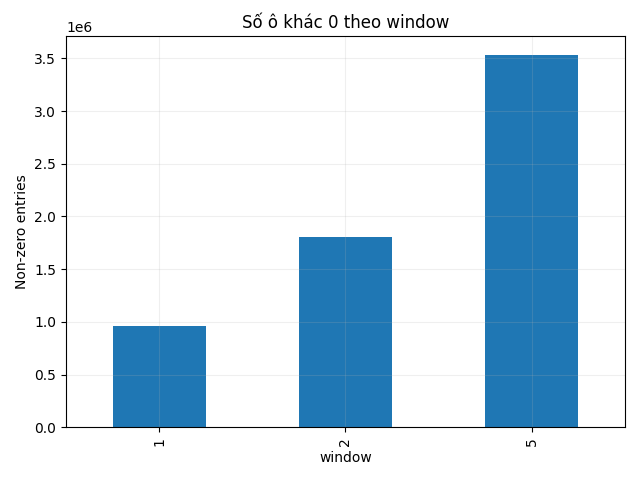

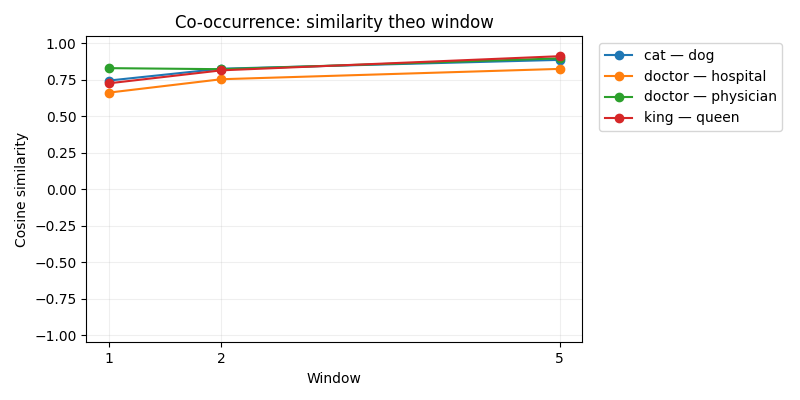

In [6]:
cooccurrence_statistics.set_index("window")[["non_zero_values"]].plot.bar(
    legend=False, title="Số ô khác 0 theo window", ylabel="Non-zero entries")
plt.tight_layout()
plt.show()
plt.close()
plot_similarity_table(cooccurrence_similarity_table,
                      "Co-occurrence: similarity theo window", "Window")


| Window | Vocabulary | Kích thước | Ô khác 0 | Density | CSR (MiB) | Build lần đã lưu (s) |
|---:|---:|---|---:|---:|---:|---:|
| 1 | 5.000 | 5.000 × 5.000 | 962.037 | 3,8481% | 11,03 | 6,35 |
| 2 | 5.000 | 5.000 × 5.000 | 1.801.117 | 7,2045% | 20,63 | 8,88 |
| 5 | 5.000 | 5.000 × 5.000 | 3.534.798 | 14,1392% | 40,47 | 15,89 |

Vocabulary và shape giữ nguyên vì `min_count=5`, `max_size=5000` được chọn trước
khi đổi window. Window chỉ thay đổi những cặp được đếm. Với cách đếm hai phía và
không có trọng số khoảng cách, mở rộng window bổ sung cặp, nên `nnz` không giảm.
Window 5 có khoảng 3,67 lần số ô khác 0 của window 1 và cần nhiều bộ nhớ/thời gian hơn.

Cosine không tăng đều: `doctor–physician` là 0,8301 → 0,8229 → 0,8972;
`doctor–hospital` là 0,6622 → 0,7542 → 0,8250; `cat–dog` là
0,7449 → 0,8264 → 0,8868. Ngay cặp đầu tiên đã giảm khi window tăng 1 lên 2.
Mỗi hàng đếm được thay đổi và chuẩn hóa lại, nên thêm context không bảo đảm tăng cosine.

`automobile` có 20 lần, `banana` có 42 lần trong corpus nhưng bị loại bởi giới hạn
top 5.000; từ có tần suất thấp nhất được giữ có 72 lần. Vì vậy hai cặp
`car–automobile`, `computer–banana` được ghi OOV/N/A, không thay bằng 0.
Đây là trade-off của vocabulary cap; không dùng các ô N/A để kết luận hai từ không liên quan.

Ma trận dense int64 cùng shape cần khoảng 190,73 MiB chỉ cho các giá trị;
CSR window 5 dùng 40,47 MiB. Số CSR chưa gồm vocabulary, bộ đếm Python và các
mảng tạm lúc xây. Cosine co-occurrence thường cao bởi các context phổ biến;
điểm cao giữa các từ cùng chủ đề không tự chứng minh chúng đồng nghĩa.


# 17. Experiment 2 — Word2Vec

Baseline: **CBOW + negative sampling**, `vector_size=100`, `window=5`, `min_count=2`,
`epochs=10`, `sg=0`, `negative=5`, `hs=0`, `sample=1e-3`, `workers=1`, `seed=42`.
Vocabulary có **55.085 từ**; mỗi từ có vector 100 chiều, được học từ cùng 10.000 documents.
CBOW dùng context để dự đoán target; negative sampling dùng 5 mẫu âm cho mỗi ví dụ
theo cấu hình, còn hierarchical softmax bị tắt. Các tham số này được báo tường minh
để người đọc biết model đã học bằng objective nào.

`shrink_windows=False` cố định bán kính trên chuỗi từ mà Gensim dùng trong training.
Min-count và subsampling vẫn có thể lược từ; vì vậy thống kê context thô ở phần 18
là bằng chứng mô tả corpus, không phải bản ghi chính xác mọi training pair.
Theo [API Word2Vec của Gensim](https://radimrehurek.com/gensim/models/word2vec.html),
`window` là khoảng cách context tối đa trong câu, `sg=0` chọn CBOW và `negative>0` bật negative sampling.

Lần train baseline đã lưu mất **1,25 s** build vocabulary và **45,12 s** train,
tổng **46,36 s**. Đây là số đo trên môi trường chạy lần đó, không phải cam kết thời gian
cho máy khác. Model 100 chiều/window 5 được dùng lại trong các thí nghiệm sau.
Cache có chữ ký corpus, tokenizer, phiên bản Gensim và cấu hình; không dùng lẫn model
đã học trên corpus khác. Chỉ có **5 cấu hình CBOW khác nhau** cần train trong notebook.


In [7]:
def stable_word_hash(word):
    return int.from_bytes(hashlib.sha256(word.encode("utf-8")).digest()[:4], "little")


model_cache, model_statistics = {}, {}


def get_model(vector_size=100, window=5):
    config = {**BASE_W2V_CONFIG, "vector_size": vector_size, "window": window}
    # Chữ ký giúp dùng lại đúng model khi chạy lại notebook.
    signature = {"corpus": CORPUS_FINGERPRINT, "config": config,
                 "gensim": importlib.metadata.version("gensim"), "hash": "sha256-32-v1"}
    key = hashlib.sha256(json.dumps(signature, sort_keys=True).encode()).hexdigest()
    if key in model_cache:
        return model_cache[key]
    name = f"{'skipgram' if config['sg'] else 'cbow'}-d{vector_size}-w{window}-{key[:16]}"
    model_path = MODEL_CACHE_DIR / f"{name}.model"
    metadata_path = MODEL_CACHE_DIR / f"{name}.json"

    if CACHE_MODELS and model_path.is_file() and metadata_path.is_file():
        metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
        if metadata["signature"] != signature:
            raise ValueError("Model đã lưu không khớp corpus hoặc cấu hình")
        model = Word2Vec.load(str(model_path))
        stat = {**metadata["training"], "cache_origin": "disk"}
        print(f"Đọc model đã lưu: {name}")
    else:
        print(f"Đang train: dimension={vector_size}, window={window}", flush=True)
        model = Word2Vec(**config, hashfxn=stable_word_hash)
        start = perf_counter()
        model.build_vocab(sentences)
        build_seconds = perf_counter() - start
        if not len(model.wv):
            raise ValueError("Vocabulary Word2Vec rỗng")
        start = perf_counter()
        model.train(sentences, total_examples=model.corpus_count, epochs=config["epochs"])
        train_seconds = perf_counter() - start
        weights = [model.wv.vectors, getattr(model, "syn1neg", None), getattr(model, "syn1", None)]
        stat = {**config, "vocabulary_size": len(model.wv),
                "build_seconds": build_seconds, "train_seconds": train_seconds,
                "total_seconds": build_seconds + train_seconds,
                "weights_bytes": sum(array.nbytes for array in weights if array is not None),
                "model_file_bytes": None, "cache_origin": "trained"}
        if CACHE_MODELS:
            MODEL_CACHE_DIR.mkdir(parents=True, exist_ok=True)
            model.save(str(model_path), sep_limit=2**63 - 1)
            stat["model_file_bytes"] = model_path.stat().st_size
            metadata_path.write_text(json.dumps({"signature": signature, "training": stat},
                                                ensure_ascii=False, indent=2), encoding="utf-8")
    model._lab_cache_key = key
    model_cache[key], model_statistics[key] = model, stat
    return model


def training_record(model):
    return model_statistics[model._lab_cache_key].copy()


def safe_similarity(model, first, second):
    if first not in model.wv or second not in model.wv:
        return np.nan
    return float(model.wv.similarity(first, second))


def similarity_frame(models, parameter):
    return pd.DataFrame([
        {parameter: value, "pair": f"{first} — {second}",
         "word": first, "other_word": second, "cosine": safe_similarity(model, first, second),
         "status": "OK" if first in model.wv and second in model.wv else "OOV"}
        for value, model in models.items() for first, second in SIMILARITY_PAIRS
    ])

In [8]:
baseline = get_model(vector_size=100, window=5)
stat = training_record(baseline)
report = pd.Series({
    "Corpus": str(DATA_PATH), "Documents": len(documents), "Sentences": len(sentences),
    "Tokens": sum(map(len, sentences)), "Vocabulary size": len(baseline.wv),
    "Embedding dimension": baseline.vector_size, "Window": baseline.window,
    "Min count": baseline.min_count, "Epochs": baseline.epochs,
    "Training objective": "CBOW + negative sampling" if baseline.sg == 0 else "Skip-gram + negative sampling",
    "Negative samples": baseline.negative, "Build vocabulary (s)": stat["build_seconds"],
    "Training (s)": stat["train_seconds"], "Cache origin": stat["cache_origin"],
}, name="Giá trị")
display(report.to_frame())
show_table(pd.DataFrame([
    {"word": word, "frequency": int(baseline.wv.get_vecattr(word, "count"))}
    for word in baseline.wv.index_to_key[:20]
]))

Đọc model đã lưu: cbow-d100-w5-054e64298baa5692


,Giá trị
Corpus,D:\Study\Study_Class\Semester_7\NLP\Lab\data\c...
Documents,10000
Sentences,207954
Tokens,3634366
Vocabulary size,55085
Embedding dimension,100
Window,5
Min count,2
Epochs,10
Training objective,CBOW + negative sampling


,word,frequency
0,the,186029
1,and,107895
2,to,103091
3,of,89425
4,a,81383
5,in,64431
6,is,44202
7,for,41369
8,you,33934
9,that,33209


# 18. Inspect embeddings

Lấy Top-5 cho cả 7 từ. Tần suất giúp kiểm tra độ ít/nhiều dữ liệu của một kết quả.
Thu thập context trong cùng câu, kèm Doc ID và dòng JSONL của corpus gốc.
Từ ngữ cảnh chung được xếp theo `min(count_query, count_neighbor)` sau bộ lọc
stopwords. Đây là bằng chứng mô tả corpus để đọc và giải thích kết quả.


In [9]:
top5_results = {}
inspection_rows = []
for query in PROBES:
    neighbors = baseline.wv.most_similar(query, topn=5) if query in baseline.wv else []
    top5_results[query] = neighbors
    if not neighbors:
        print(f"{query}: OOV")
    for rank, (neighbor, score) in enumerate(neighbors, start=1):
        inspection_rows.append({
            "query": query, "rank": rank, "neighbor": neighbor, "cosine": float(score),
            "query_frequency": int(baseline.wv.get_vecattr(query, "count")),
            "neighbor_frequency": int(baseline.wv.get_vecattr(neighbor, "count")),
        })
inspection_table = pd.DataFrame(inspection_rows, columns=[
    "query", "rank", "neighbor", "cosine", "query_frequency", "neighbor_frequency"])
show_table(inspection_table)


,query,rank,neighbor,cosine,query_frequency,neighbor_frequency
0,doctor,1,physician,0.7251,264,86
1,doctor,2,surgeon,0.6933,264,117
2,doctor,3,dentist,0.6626,264,49
3,doctor,4,medication,0.6553,264,87
4,doctor,5,veterinarian,0.6484,264,20
5,hospital,1,clinic,0.7308,356,107
6,hospital,2,medical,0.6355,356,790
7,hospital,3,emory,0.6345,356,8
8,hospital,4,nursing,0.6250,356,119
9,hospital,5,tucson,0.6192,356,13


In [10]:
focus_words = {word for word in PROBES if word in baseline.wv}
for neighbors in top5_results.values():
    focus_words.update(word for word, _ in neighbors)
context_counts = {word: Counter() for word in focus_words}
context_positions = {word: [] for word in focus_words}
print("Đang lấy bằng chứng từ corpus...", flush=True)
for doc_index, doc in enumerate(document_sentences):
    for sentence_index, tokens in enumerate(doc):
        for position, word in enumerate(tokens):
            if word in focus_words:
                start, end = max(0, position - baseline.window), position + baseline.window + 1
                context_counts[word].update(tokens[start:position])
                context_counts[word].update(tokens[position + 1:end])
                context_positions[word].append((doc_index, sentence_index, position))

shared_contexts_by_pair = {}
context_rows = []
for query, neighbors in top5_results.items():
    for neighbor, score in neighbors:
        common = [word for word in set(context_counts[query]) & set(context_counts[neighbor])
                  if word not in STOPWORDS and word not in {query, neighbor}
                  and word.isalpha() and len(word) > 2]
        common.sort(key=lambda word: (-min(context_counts[query][word],
                                           context_counts[neighbor][word]), word))
        shared = common[:5]
        shared_contexts_by_pair[(query, neighbor)] = shared
        context_rows.append({
            "query": query, "neighbor": neighbor, "cosine": float(score),
            "shared_context_query_neighbor": "; ".join(
                f"{word} ({context_counts[query][word]}/{context_counts[neighbor][word]})"
                for word in shared) or "Chưa có sau bộ lọc",
            "direct_cooccurrences": context_counts[query][neighbor],
        })
context_evidence_table = pd.DataFrame(context_rows)
show_table(context_evidence_table)


def context_examples(word, shared_words=(), limit=2):
    shared_words = set(shared_words)
    rows, used_docs = [], set()
    for doc_index, sentence_index, position in context_positions.get(word, []):
        if doc_index in used_docs:
            continue
        tokens = document_sentences[doc_index][sentence_index]
        context = tokens[max(0, position - baseline.window):position] + tokens[
            position + 1:position + baseline.window + 1]
        if shared_words and not shared_words.intersection(context):
            continue
        radius = max(8, baseline.window)
        start = max(0, position - radius)
        excerpt = tokens[start:position + radius + 1].copy()
        excerpt[position - start] = f"[{word}]"
        rows.append({"word": word, "doc_id": doc_index + 1,
                     "jsonl_line": source_line_numbers[doc_index],
                     "sentence_id": sentence_index + 1, "context": " ".join(excerpt)})
        used_docs.add(doc_index)
        if len(rows) >= limit:
            break
    return pd.DataFrame(rows)


def show_word_evidence(query="doctor", examples_per_word=2):
    if not top5_results.get(query):
        print(f"{query}: OOV hoặc chưa có Top-5")
        return
    for neighbor, score in top5_results[query]:
        display(Markdown(f"### {query} — {neighbor} | cosine = {score:.4f}"))
        shared = shared_contexts_by_pair[(query, neighbor)]
        print("Context chung:", ", ".join(shared) or "Chưa có sau bộ lọc")
        show_table(pd.concat([context_examples(word, shared, examples_per_word)
                              for word in (query, neighbor)], ignore_index=True))

show_word_evidence("doctor")


Đang lấy bằng chứng từ corpus...
Context chung: care, health, medical, advice, said
Context chung: eye, ask, lasik, find, said
Context chung: visit, important, one, see, best
Context chung: order, time, appropriate, care, eye
Context chung: call, consult, visit, able, ask


,query,neighbor,cosine,shared_context_query_neighbor,direct_cooccurrences
0,doctor,physician,0.7251,care (9/13); health (8/5); medical (5/6); advi...,0
1,doctor,surgeon,0.6933,eye (18/20); ask (6/6); lasik (6/22); find (4/...,2
2,doctor,dentist,0.6626,visit (6/4); important (3/3); one (3/3); see (...,1
3,doctor,medication,0.6553,order (7/3); time (6/3); appropriate (2/2); ca...,1
4,doctor,veterinarian,0.6484,call (2/2); consult (8/2); visit (6/2); able (...,0
5,hospital,clinic,0.7308,health (15/8); care (14/7); affiliated (5/5); ...,3
6,hospital,medical,0.6355,university (29/38); health (15/31); care (14/3...,15
7,hospital,emory,0.6345,creek (3/3); johns (3/3); university (29/3); a...,3
8,hospital,nursing,0.6250,care (14/14); university (29/7); medical (15/6...,1
9,hospital,tucson,0.6192,medicine (6/2); advocate (1/1); center (5/1); ...,0


### doctor — physician | cosine = 0.7251

,word,doc_id,jsonl_line,sentence_id,context
0,doctor,794,794,7,the [doctor] said that it was the type of frac...
1,doctor,1264,1264,47,are taking blood thinners you should ask your ...
2,physician,130,130,9,ajayi was an attending [physician] at boston m...
3,physician,169,169,36,of doctors who have been the primary care [phy...


### doctor — surgeon | cosine = 0.6933

...

,word,doc_id,jsonl_line,sentence_id,context
0,doctor,1131,1131,9,by affluent families who tend to visit the [do...
1,doctor,2266,2266,3,a rural hospital it's important to get a [doct...
2,dentist,925,925,1,why is it important to see a [dentist] in weat...
3,dentist,1898,1898,13,significant plaque build up in between visits ...


### doctor — medication | cosine = 0.6553

,word,doc_id,jsonl_line,sentence_id,context
0,doctor,1747,1747,293,geet on the sudden order passed by her [doctor...
1,doctor,2266,2266,18,however the [doctor] will have lost valuable t...
2,medication,1606,1606,55,during the time he was on this [medication] he...
3,medication,2481,2481,4,the pharmacist make time to explain each new [...


### doctor — veterinarian | cosine = 0.6484

,word,doc_id,jsonl_line,sentence_id,context
0,doctor,1131,1131,9,by affluent families who tend to visit the [do...
1,doctor,1264,1264,47,are taking blood thinners you should ask your ...
2,veterinarian,381,381,74,to keep your pet calm and call your [veterinar...
3,veterinarian,2809,2809,38,pet rabbit will n d t visit th [veterinarian] ...


### Nhận xét Top-5 và bằng chứng từ corpus

#### Doctor

`physician` 0,7251, `surgeon` 0,6933, `dentist` 0,6626, `medication`
0,6553, `veterinarian` 0,6484. `physician` gần nghĩa nhất với doctor;
context chung là `care (9/13)`, `health (8/5)`, `medical (5/6)`. Doc 130/câu 9
có “attending physician at Boston Medical Center”. Hai từ không đứng cạnh nhau
trong cửa sổ đã đếm (`direct_cooccurrences=0`), nhưng vẫn có vector gần: bằng chứng
phù hợp với distributional hypothesis về context tương tự.

`surgeon` có `eye (18/20)`, `lasik (6/22)` chung với doctor, gợi ý context điều trị mắt.
`dentist` chia sẻ `visit (6/4)` và `see (5/3)`; Doc 1131/câu 9 có “visit the doctor”,
Doc 925/câu 1 có “see a dentist”. `medication` là thuốc, không phải nghề nghiệp:
`order (7/3)`, `appropriate (2/2)` cho thấy liên hệ điều trị, không phải đồng nghĩa.
`veterinarian` cùng các context `call (2/2)`, `consult (8/2)`, `visit (6/2)`;
Doc 381/câu 74 có “call your veterinarian”. Từ này chỉ có 20 lần, nên bằng chứng
về hàng xóm này ít hơn doctor 264 lần; không nên kết luận mọi neighbor đều cùng nghĩa.

#### Hospital

`clinic` 0,7308, `medical` 0,6355, `emory` 0,6345, `nursing` 0,6250,
`tucson` 0,6192. Clinic và nursing hợp lý theo chủ đề chăm sóc: hospital/clinic
chia sẻ `health (15/8)`, `care (14/7)`, còn hospital/nursing có `care (14/14)`.
Doc 455/câu 66 chứa “Pre-Hospital Health Care”; Doc 1128 mô tả medical center
và clinic hợp nhất. `medical` là từ chỉ thuộc tính/chủ đề, không phải từ đồng nghĩa hospital.

Hai tên riêng cần đọc nguồn: `emory` chỉ 8 lần; Doc 5138 có “Emory Johns Creek Hospital”
ở ba câu, giải thích liên hệ hospital–emory. `tucson` chỉ 13 lần;
Doc 3467/câu 78 có “College of Medicine in Tucson”. Các tên riêng gần hospital có thể
phản ánh cơ sở/địa điểm được nói tới trong một phần corpus, không phải khái niệm bệnh viện nói chung.

#### Patient

`diagnosis` **0,7100**, `physician` **0,6365**, `medication` **0,6297**, `patients`
**0,6210**, `illness` **0,6155**. Diagnosis đứng trên cả dạng số nhiều patients:
model xếp theo context đã học, không theo quan hệ hình thái hay từ đồng nghĩa.
Patient/diagnosis chung `treatment (6/14)`, `medical (7/4)`, `symptoms (5/4)`;
Doc 675/câu 6 có “patient treatment acceptance”, Doc 245/câu 30 có “clinical diagnosis”.
Patient/physician có `care (29/13)`; patient/medication có `taking (3/3)` và
`treatment (6/3)`; patient/illness có `symptoms (5/3)`. Các từ này biểu diễn bệnh nhân,
bác sĩ, thuốc, chẩn đoán và bệnh trong cùng hoạt động y tế, không thể thay thế nhau tùy ý.
Tokenizer không lemmatize, nên `patient` (320 lần) và `patients` (547 lần) là hai token riêng.

#### Disease

`chronic` 0,8442, `syndrome` 0,8199, `infection` 0,8124, `infections`
0,8035, `severe` 0,8024. Chronic và severe là các từ thường mô tả bệnh,
không phải danh từ đồng nghĩa disease. Disease/chronic có `pulmonary (6/6)`,
`patients (18/14)`; disease/infection có `control (15/8)`, `risk (18/7)`;
disease/severe có `cause (11/7)`, `symptoms (4/6)`. Doc 1059/câu 3 có “chronic diseases”,
Doc 1590/câu 5 chứa “infection … chronic pain”. Syndrome chia sẻ `heart`, `bowel`,
`chronic` với disease. Infection và infections là hai token do không lemmatize.
Top-5 này cho thấy quan hệ chủ đề và cách dùng trong câu có thể mạnh hơn đồng nghĩa.

#### Computer

`device` 0,7295, `desktop` 0,6792, `software` 0,6618, `server` 0,6515,
`browser` 0,6462. Device là khái niệm rộng, desktop là loại máy tính;
software/browser là chương trình, còn server là thiết bị hoặc vai trò trong hệ thống.
Computer/desktop có `laptop (13/7)`, `mobile (7/7)`, `applications (9/6)`;
Doc 2150/câu 5 chứa “desktop computer”. Computer/software có `data (12/15)`,
`security (12/21)`; computer/server có `software (29/8)`; computer/browser có
`cookies (6/7)`, `save (7/7)`. Đây là bằng chứng về môi trường sử dụng máy tính,
không phải tất cả năm từ đều có cùng nghĩa với computer.

#### Football

`replica` 0,7932, `baseball` 0,5796, `shirt` 0,5404, `basketball` 0,5399,
`demon` 0,5278. Baseball và basketball có context thể thao chung: football/baseball
có `league (13/6)`, `player (11/6)`; football/basketball có `team (13/10)`, `play (9/11)`.
Replica đứng Top-1 là trường hợp cần phân tích dữ liệu: **Doc 6083 chứa 344/573 lần football
và 163/183 lần replica**, lặp cụm “replica football shirt” trong văn bản không mạch lạc.
Toàn bộ 254 lần đếm football→replica trong cửa sổ 5 đều nằm ở document này;
đây là số cặp context, không phải 254 câu hay 254 lần riêng biệt của cụm.
Context chung `shirt (245/171)`, `kits (89/26)` phù hợp với ảnh hưởng của nội dung áo bóng đá.
Doc này còn chứa 8/21 lần demon, hỗ trợ giả thuyết dữ liệu nhiễu làm demon vào Top-5.
Chưa có thí nghiệm bỏ Doc 6083 rồi train lại, nên không khẳng định tác động nhân quả đã được chứng minh.

#### Banana

`cinnamon` 0,7251, `parsley` 0,7212, `onions` 0,7142, `feeder` 0,7078,
`mugs`0,7024. Banana chỉ 42 lần; các neighbor lần lượt có 35, 16, 51, 23, 9 lần.
Cinnamon/parsley/onions có context chế biến thực phẩm như `add`, `blender`, `pan`, `peppers`;
Doc 16/câu 88 có “banana bread/meatloaf pan”. Điều này hỗ trợ quan hệ nguyên liệu/chủ đề,
không chứng minh các từ đều gần nghĩa với chuối. Banana/feeder chỉ có context chung
`bowl (1/5)`; banana/mugs chỉ có `coffee (1/2)` sau bộ lọc. Doc 2512/câu 95 có
“coffee festivals, banana festivals”, còn Doc 7972/câu 19 có “coffee mugs … nutmeg”.
Hai cặp cuối có ít bằng chứng context chung; tần suất thấp là một nguyên nhân có thể,
nhưng cần thêm dữ liệu hoặc kiểm tra seed trước khi kết luận.



# 19. Experiment 3 — Context window

Window **2, 5, 10**; dimension 100 và các tham số còn lại giữ cố định.
Model window 5 được dùng lại từ Experiment 2.


Đọc model đã lưu: cbow-d100-w2-54286849579c75ba
Đọc model đã lưu: cbow-d100-w10-6c9aa90032ebebb1


window,pair,2,5,10
0,car — automobile,0.4704,0.3343,0.3360
1,cat — dog,0.6638,0.5778,0.5993
2,computer — banana,0.1536,0.0257,-0.1744
3,doctor — hospital,0.4730,0.5331,0.5824
4,doctor — physician,0.7745,0.7251,0.8066
5,king — queen,0.7303,0.6344,0.6169


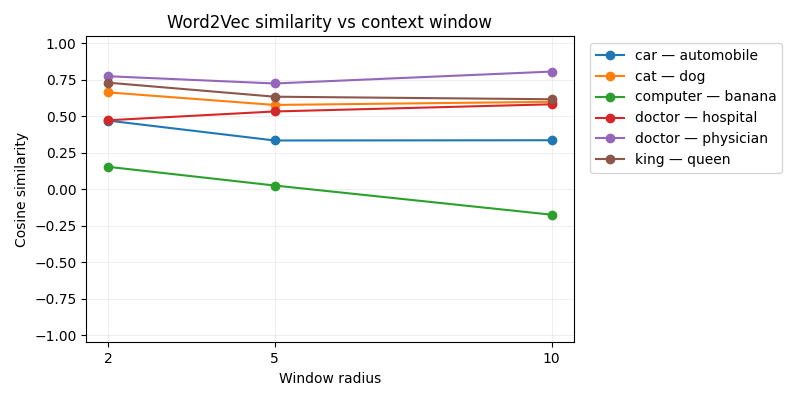

In [11]:
window_models = {window: get_model(vector_size=100, window=window) for window in (2, 5, 10)}
window_similarity_long = similarity_frame(window_models, "window")
window_similarity_table = window_similarity_long.pivot(index="pair", columns="window", values="cosine")
show_table(window_similarity_table.reset_index())
plot_similarity_table(window_similarity_table,
                      "Word2Vec similarity vs context window", "Window radius")


### Window lớn hơn có luôn tốt hơn không?

| Cặp từ | Window 2 | Window 5 | Window 10 |
|---|---:|---:|---:|
| doctor–physician | 0,7745 | 0,7251 | 0,8066 |
| doctor–hospital | 0,4730 | 0,5331 | 0,5820 |
| cat–dog | 0,6638 | 0,5778 | 0,5993 |
| car–automobile | 0,4704 | 0,3343 | 0,3360 |
| king–queen | 0,7303 | 0,6344 | 0,6169 |
| computer–banana | 0,1536 | 0,0257 | -0,1744 |

Không. Doctor–physician giảm 0,0495 khi tăng window 2 lên 5 rồi tăng khi lên 10;
cat–dog và car–automobile cũng không tăng đều. Doctor–hospital tăng đều trong lần chạy này,
phù hợp với giả thuyết cửa sổ rộng thu thêm thông tin chủ đề y tế. Đây là diễn giải có thể,
chưa phải chứng minh nguyên nhân từ một seed duy nhất.

Window nhỏ tập trung các từ gần và cách sử dụng cục bộ; window lớn thêm các từ xa hơn,
có thể thể hiện chủ đề rộng nhưng cũng thêm nhiễu. Cặp ít liên quan computer–banana giảm,
trong khi một số cặp liên quan khác cũng giảm, nên không đánh giá chất lượng chỉ bằng
“mọi cosine càng lớn càng tốt”. Cosine âm biểu thị góc tù trong không gian vector,
không tự động có nghĩa hai từ là từ trái nghĩa.

Thời gian train gốc window 2/5/10 là 47,82 / 45,12 / 67,79 s. Window 10 chậm hơn
trong số đo này, nhưng window 5 nhanh hơn 2 cho thấy số đo còn chịu ảnh hưởng môi trường,
không đủ để khẳng định quan hệ thời gian tuyệt đối từ một lần chạy. Cần chọn window theo
similarity/analogy hoặc downstream task mong muốn, không có window tốt nhất cho mọi bài toán.


# 20. Experiment 4 — Embedding dimension

Dimension 50, 100, 300, window 5. Giữ nguyên corpus, min_count, epochs,
objective, negative sampling, seed và workers. Đánh giá thời gian, dung lượng,
similarity, analogy và downstream retrieval trên C4.

`weights_mib` đo các mảng trọng số. `model_file_mib` đo file model đã lưu
nếu bật cache. Thời gian gồm build vocabulary và training, được báo riêng
cùng tổng thời gian. Model 100 chiều được dùng lại.


Đọc model đã lưu: cbow-d50-w5-24d6b56235b0304b
Đọc model đã lưu: cbow-d300-w5-1a4d149f4c045912


,dimension,vocabulary_size,build_seconds,train_seconds,total_seconds,weights_mib,model_file_mib,cache_origin
0,50,55085,1.1339,61.3628,62.4967,21.0133,22.6040,disk
1,100,55085,1.2475,45.1164,46.3639,42.0265,43.6173,disk
2,300,55085,1.2190,76.8681,78.0871,126.0796,127.6703,disk


dimension,pair,50,100,300
0,car — automobile,0.3511,0.3343,0.3386
1,cat — dog,0.7017,0.5778,0.5793
2,computer — banana,0.0517,0.0257,0.0395
3,doctor — hospital,0.5629,0.5331,0.5376
4,doctor — physician,0.7671,0.7251,0.7207
5,king — queen,0.7112,0.6344,0.6328


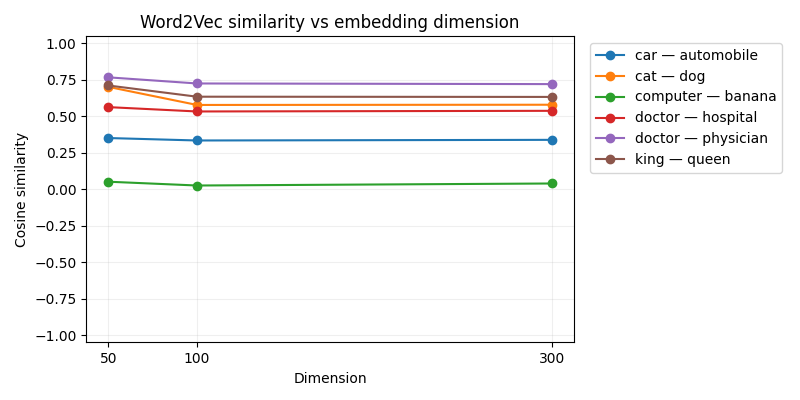

In [12]:
dimension_models = {dimension: get_model(vector_size=dimension, window=5) for dimension in (50, 100, 300)}
dimension_resource_rows = []
for dimension, model in dimension_models.items():
    stat = training_record(model)
    dimension_resource_rows.append({
        "dimension": dimension, "vocabulary_size": len(model.wv),
        "build_seconds": stat["build_seconds"], "train_seconds": stat["train_seconds"],
        "total_seconds": stat["total_seconds"], "weights_mib": stat["weights_bytes"] / 2**20,
        "model_file_mib": stat["model_file_bytes"] / 2**20 if stat["model_file_bytes"] is not None else np.nan,
        "cache_origin": stat["cache_origin"],
    })
dimension_resources = pd.DataFrame(dimension_resource_rows)
dimension_similarity_long = similarity_frame(dimension_models, "dimension")
dimension_similarity_table = dimension_similarity_long.pivot(index="pair", columns="dimension", values="cosine")
show_table(dimension_resources)
show_table(dimension_similarity_table.reset_index())
plot_similarity_table(dimension_similarity_table,
                      "Word2Vec similarity vs embedding dimension", "Dimension")


### Analogy — Đánh giá ba model dimension

In [13]:
analogy_rows, analogy_summary_rows = [], []
for dimension, model in dimension_models.items():
    evaluated = hit1 = hit5 = 0
    for a, b, c, expected in ANALOGIES:
        missing = [word for word in (a, b, c, expected) if word not in model.wv]
        row = {"dimension": dimension, "analogy": f"{a} - {b} + {c}",
               "expected": expected, "top1": "", "top5": "",
               "hit1": np.nan, "hit5": np.nan,
               "status": "OOV: " + ", ".join(missing) if missing else "OK"}
        if not missing:
            candidates = model.wv.most_similar(positive=[a, c], negative=[b], topn=5)
            words = [word for word, _ in candidates]
            evaluated += 1
            row.update(top1=words[0], top5=", ".join(words),
                       hit1=int(words[0] == expected), hit5=int(expected in words))
            hit1 += row["hit1"]
            hit5 += row["hit5"]
        analogy_rows.append(row)
    analogy_summary_rows.append({
        "dimension": dimension, "analogy_evaluated": evaluated, "analogy_total": len(ANALOGIES),
        "analogy_hit1": hit1 / evaluated if evaluated else np.nan,
        "analogy_hit5": hit5 / evaluated if evaluated else np.nan,
    })
analogy_details = pd.DataFrame(analogy_rows)
analogy_summary = pd.DataFrame(analogy_summary_rows)
show_table(analogy_details)
show_table(analogy_summary)


,dimension,analogy,expected,top1,top5,hit1,hit5,status
0,50,king - man + woman,queen,queen,"queen, shocking, birendra, harry, duo",1,1,OK
1,50,paris - france + italy,rome,haven,"haven, opera, theatre, melbourne, madison",0,0,OK
2,50,man - boy + girl,woman,woman,"woman, horse, person, satan, modeler",1,1,OK
3,100,king - man + woman,queen,queen,"queen, harry, fincham, untitled, duo",1,1,OK
4,100,paris - france + italy,rome,opera,"opera, festival, tuscany, theatre, palace",0,0,OK
5,100,man - boy + girl,woman,woman,"woman, person, satan, horse, child",1,1,OK
6,300,king - man + woman,queen,queen,"queen, fincham, harry, rodgers, duo",1,1,OK
7,300,paris - france + italy,rome,opera,"opera, festival, tuscany, palace, theatre",0,0,OK
8,300,man - boy + girl,woman,woman,"woman, person, satan, mystery, creature",1,1,OK


,dimension,analogy_evaluated,analogy_total,analogy_hit1,analogy_hit5
0,50,3,3,0.6667,0.6667
1,100,3,3,0.6667,0.6667
2,300,3,3,0.6667,0.6667


### Downstream task — Tìm lại document nguồn từ một câu C4

1. Chọn tối đa 20 documents bằng seed cố định; lấy một câu ở giữa mỗi document
   có 8–35 tokens và ít nhất 5 từ nội dung đã có trong vocabulary.
2. Dùng câu thật đó làm query. **Bỏ đúng lần xuất hiện của câu này khỏi bag-of-words
   của document nguồn** trước khi tạo vector tài liệu. Giữ nguyên văn bản gốc để đọc.
3. Tìm trong toàn bộ corpus bằng trung bình word vectors, chuẩn hóa L2.
   Cùng query và cùng candidate documents được dùng cho mọi dimension và TF-IDF.
4. Đáp án của phép thử là Doc ID nguồn. Hit@1/5, MRR và nDCG@5 đo khả năng
   tìm lại nguồn này. Query không có vector được tính là thất bại và báo coverage.

Đây là **known-item retrieval**, khác với chấm độ liên quan theo chủ đề.
Câu query được lấy khỏi biểu diễn tài liệu khi search; Word2Vec vẫn được học
trên toàn bộ corpus đã chọn. Đánh giá này là in-sample ở bước học embedding.
Các bản gần trùng của một document có thể làm giảm điểm tìm đúng ID nguồn.

TF-IDF dùng [TfidfTransformer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfTransformer.html):
`sublinear_tf=True` (TF = 1 + log(count)), IDF có smoothing và chuẩn hóa L2.
Query dùng transformer đã fit trên documents, không fit lại trên query.


In [14]:
search_vocabulary = baseline.wv.index_to_key
search_word_id = {word: index for index, word in enumerate(search_vocabulary)}


def search_tokens(tokens):
    return [word for word in tokens if word not in STOPWORDS and word in search_word_id]


# Chọn câu thật từ corpus; giữ seed và tiêu chí cố định cho mọi model.
rng = np.random.default_rng(SEED)
query_rows, used_queries = [], set()
for doc_index in rng.permutation(len(document_sentences)):
    doc = document_sentences[int(doc_index)]
    total_tokens = sum(map(len, doc))
    if len(doc) < 3 or total_tokens < 60:
        continue
    eligible = [i for i in range(1, len(doc) - 1)
                if 8 <= len(doc[i]) <= 35 and len(set(search_tokens(doc[i]))) >= 5
                and total_tokens - len(doc[i]) >= 40]
    if not eligible:
        continue
    sentence_index = int(rng.choice(eligible))
    query = " ".join(doc[sentence_index])
    if query in used_queries:
        continue
    query_rows.append({"query_id": len(query_rows) + 1, "query": query,
                       "gold_doc_id": int(doc_index) + 1,
                       "jsonl_line": source_line_numbers[int(doc_index)],
                       "sentence_id": sentence_index + 1})
    used_queries.add(query)
    if len(query_rows) == RETRIEVAL_QUERY_COUNT:
        break
retrieval_cases = pd.DataFrame(query_rows)
if retrieval_cases.empty:
    raise ValueError("Corpus chưa đủ documents phù hợp; hãy tăng MAX_DOCUMENTS")


def document_bow(heldout_cases=None):
    excluded = {} if heldout_cases is None else {
        int(row.gold_doc_id) - 1: int(row.sentence_id) - 1
        for row in heldout_cases.itertuples(index=False)}
    indptr, indices, data = [0], [], []
    for doc_index, doc in enumerate(document_sentences):
        counts = Counter(word for i, tokens in enumerate(doc)
                         if i != excluded.get(doc_index, -1) for word in search_tokens(tokens))
        indices.extend(search_word_id[word] for word in counts)
        data.extend(counts.values())
        indptr.append(len(indices))
    bow = sparse.csr_matrix((np.array(data, dtype=np.float32), indices, indptr),
                            shape=(len(documents), len(search_vocabulary)))
    bow.sort_indices()  # Giữ thứ tự cộng nhất quán khi nhân ma trận.
    return bow


def document_embeddings(bow, model):
    if model.wv.index_to_key != search_vocabulary:
        raise ValueError("Thứ tự vocabulary giữa các model khác nhau")
    totals = np.asarray(bow.sum(axis=1)).ravel()[:, None]
    vectors = bow @ model.wv.vectors
    vectors = np.divide(vectors, totals, out=np.zeros_like(vectors), where=totals > 0)
    norms = np.linalg.norm(vectors, axis=1, keepdims=True)
    return np.divide(vectors, norms, out=np.zeros_like(vectors), where=norms > 0)


def query_embedding(query, model):
    content = [word for word in tokenizer.tokenize_sentence(query) if word not in STOPWORDS]
    known = [word for word in content if word in model.wv]
    vector = model.wv[known].mean(axis=0) if known else np.zeros(model.vector_size, dtype=np.float32)
    norm = np.linalg.norm(vector)
    return (vector / norm if norm else vector), len(known) / len(content) if content else 0.0


def build_tfidf(bow):
    transformer = TfidfTransformer(sublinear_tf=True)
    return transformer.fit_transform(bow.astype(np.float64)), transformer


def tfidf_query_scores(query, matrix, transformer):
    content = [word for word in tokenizer.tokenize_sentence(query) if word not in STOPWORDS]
    counts = Counter(search_tokens(content))
    columns = [search_word_id[word] for word in counts]
    bow = sparse.csr_matrix((list(counts.values()), ([0] * len(columns), columns)),
                            shape=(1, len(search_vocabulary)), dtype=np.float64)
    vector = transformer.transform(bow)
    scores = (matrix @ vector.T).toarray().ravel()
    return scores, sum(counts.values()) / len(content) if content else 0.0


def rank_documents(scores, valid_documents):
    ids = np.flatnonzero(valid_documents)
    return ids[np.lexsort((ids, -np.asarray(scores)[ids]))]


evaluation_bow = document_bow(retrieval_cases)
evaluation_tfidf, evaluation_transformer = build_tfidf(evaluation_bow)
show_table(retrieval_cases)
print(f"Candidate documents: {len(documents):,}; queries: {len(retrieval_cases)}")

Candidate documents: 10,000; queries: 20


,query_id,query,gold_doc_id,jsonl_line,sentence_id
0,1,even if there is a mistake due accuracy of the...,8133,8133,5
1,2,having both the lowest price and an innvovativ...,8269,8269,3
2,3,one of those species is the indiana bat an end...,720,720,10
3,4,it is defined as best quality hotel in tirana ...,8238,8238,4
4,5,according to multiple people familiar with the...,4556,4556,16
5,6,note that we are not providing the ctaul host ...,6652,6652,45
6,7,we had supper at la caverna and absolutely lov...,5651,5651,13
7,8,specifically the cases of casey stoney and meg...,1261,1261,2
8,9,internship at digital republik has helped me b...,645,645,32
9,10,not all industrial design is built of good usa...,9099,9099,2


In [15]:
def evaluate_known_item(model=None):
    name = "TF-IDF" if model is None else f"Word2Vec-{model.vector_size}"
    if model is None:
        valid_documents = np.asarray(evaluation_tfidf.getnnz(axis=1)).ravel() > 0
    else:
        vectors = document_embeddings(evaluation_bow, model)
        valid_documents = np.linalg.norm(vectors, axis=1) > 0
    rows = []
    for case in retrieval_cases.itertuples(index=False):
        start = perf_counter()
        if model is None:
            scores, coverage = tfidf_query_scores(case.query, evaluation_tfidf, evaluation_transformer)
            query_valid = coverage > 0
        else:
            query_vector, coverage = query_embedding(case.query, model)
            query_valid = np.linalg.norm(query_vector) > 0
            scores = vectors @ query_vector
        order = rank_documents(scores, valid_documents) if query_valid else np.array([], dtype=int)
        search_ms = 1000 * (perf_counter() - start)
        matches = np.flatnonzero(order == case.gold_doc_id - 1)
        rank = int(matches[0]) + 1 if len(matches) else None
        rows.append({"model": name, "dimension": model.vector_size if model is not None else np.nan,
                     "query_id": case.query_id, "query": case.query, "gold_doc_id": case.gold_doc_id,
                     "source_rank": rank, "top1_doc_id": int(order[0]) + 1 if len(order) else None,
                     "hit1": int(rank == 1), "hit5": int(rank is not None and rank <= 5),
                     "reciprocal_rank": 1 / rank if rank is not None else 0.0,
                     "ndcg5": 1 / np.log2(rank + 1) if rank is not None and rank <= 5 else 0.0,
                     "token_coverage": coverage, "query_valid": int(query_valid), "search_ms": search_ms,
                     "status": "OK" if rank is not None else "NO_QUERY_OR_SOURCE_VECTOR"})
    details = pd.DataFrame(rows)
    summary = {"model": name, "dimension": model.vector_size if model is not None else np.nan,
               "queries": len(details), "queries_with_vector": int(details["query_valid"].sum()),
               "retrieval_hit1": details["hit1"].mean(), "retrieval_hit5": details["hit5"].mean(),
               "retrieval_mrr": details["reciprocal_rank"].mean(), "retrieval_ndcg5": details["ndcg5"].mean(),
               "mean_search_ms": details["search_ms"].mean()}
    return details, summary


retrieval_tables, retrieval_summary_rows = [], []
for model in [*dimension_models.values(), None]:
    detail, summary = evaluate_known_item(model)
    retrieval_tables.append(detail)
    retrieval_summary_rows.append(summary)
retrieval_details = pd.concat(retrieval_tables, ignore_index=True)
retrieval_summary = pd.DataFrame(retrieval_summary_rows)
show_table(retrieval_summary)
show_table(retrieval_details[["model", "query_id", "gold_doc_id", "source_rank", "hit5", "status"]])


,model,dimension,queries,queries_with_vector,retrieval_hit1,retrieval_hit5,retrieval_mrr,retrieval_ndcg5,mean_search_ms
0,Word2Vec-50,50.0,20,20,0.10,0.15,0.1326,0.1315,1.1522
1,Word2Vec-100,100.0,20,20,0.10,0.15,0.1344,0.1315,1.5943
2,Word2Vec-300,300.0,20,20,0.10,0.15,0.1354,0.1315,2.1489
3,TF-IDF,NaN,20,20,0.45,0.60,0.5075,0.5193,4.5966


,model,query_id,gold_doc_id,source_rank,hit5,status
0,Word2Vec-50,1,8133,337,0,OK
1,Word2Vec-50,2,8269,298,0,OK
2,Word2Vec-50,3,720,475,0,OK
3,Word2Vec-50,4,8238,1,1,OK
4,Word2Vec-50,5,4556,293,0,OK
...,...,...,...,...,...,...
75,TF-IDF,16,3356,1,1,OK
76,TF-IDF,17,889,12,0,OK
77,TF-IDF,18,8565,1,1,OK
78,TF-IDF,19,530,3,1,OK


,dimension,vocabulary_size,total_seconds,weights_mib,model_file_mib,analogy_evaluated,analogy_total,analogy_hit1,analogy_hit5,queries,retrieval_mrr,retrieval_hit5,retrieval_ndcg5
0,50,55085,62.4967,21.0133,22.6040,3,3,0.6667,0.6667,20,0.1326,0.15,0.1315
1,100,55085,46.3639,42.0265,43.6173,3,3,0.6667,0.6667,20,0.1344,0.15,0.1315
2,300,55085,78.0871,126.0796,127.6703,3,3,0.6667,0.6667,20,0.1354,0.15,0.1315


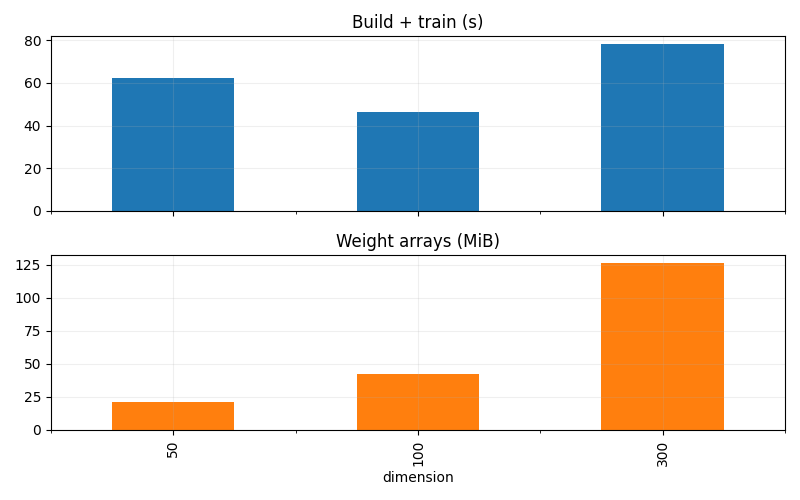

In [16]:
dimension_summary = (
    dimension_resources.merge(analogy_summary, on="dimension", validate="one_to_one")
    .merge(retrieval_summary[retrieval_summary["model"] != "TF-IDF"],
           on="dimension", validate="one_to_one")
)
show_table(dimension_summary[[
    "dimension", "vocabulary_size", "total_seconds", "weights_mib", "model_file_mib",
    "analogy_evaluated", "analogy_total", "analogy_hit1", "analogy_hit5",
    "queries", "retrieval_mrr", "retrieval_hit5", "retrieval_ndcg5",
]])
dimension_summary.set_index("dimension")[["total_seconds", "weights_mib"]].plot.bar(
    subplots=True, figsize=(8, 5), title=["Build + train (s)", "Weight arrays (MiB)"], legend=False)
plt.tight_layout()
plt.show()
plt.close()


## Kết luận Experiment 4 — Dimension, capacity, data và computation

| Dimension | Build + train gốc (s) | Weight arrays (MiB) | File model (MiB) | Analogy Hit@1/5 | Retrieval Hit@1 | Hit@5 | MRR |
|---:|---:|---:|---:|---:|---:|---:|---:|
| 50 | 62,50 | 21,01 | 22,60 | 2/3 | 0,10 | 0,15 | 0,1326 |
| 100 | 46,36 | 42,03 | 43,62 | 2/3 | 0,10 | 0,15 | 0,1344 |
| 300 | 78,09 | 126,08 | 127,67 | 2/3 | 0,10 | 0,15 | 0,1354 |

**Model size:** V=55.085 cố định, weight arrays tăng tuyến tính theo dimension:
100 chiều gấp 2 lần 50, 300 chiều gấp 6 lần 50. Bảng cộng cả input embeddings và
trọng số negative sampling float32; riêng `model.wv.vectors` bằng một nửa các số này.
File model còn có vocabulary/metadata, nên lớn hơn tổng weight arrays. Đây không phải
phép đo peak RAM của toàn bộ notebook.

**Training time:** Trong lần đo đã lưu, 100 chiều nhanh hơn 50 chiều. Vì các model được
train ở các thời điểm khác nhau và không có nhiều lần đo, chưa thể gán khác biệt này
cho dimension hoặc kết luận 100 chiều luôn nhanh hơn. 300 chiều tốn nhiều bộ nhớ và
có tổng thời gian cao nhất trong ba số đo. Khi đọc cache, bảng giữ thời gian train gốc.

**Similarity:** Doctor–physician **0,7671 → 0,7251 → 0,7207**, cat–dog
**0,7017 → 0,5778 → 0,5793**, car–automobile **0,3511 → 0,3343 → 0,3386**.
Các cặp này không cải thiện đều khi tăng dimension. Computer–banana là
**0,0517 → 0,0257 → 0,0395**; giảm similarity của một cặp ít liên quan có thể phù hợp
với intuition, nhưng chưa đủ để chọn model tốt hơn trên toàn bộ tác vụ.

**Analogy:** Cả ba model đạt Hit@1=Hit@5=**2/3 ≈ 0,6667** trên đúng ba câu.
King–man+woman và man–boy+girl ra đáp án Top-1; Paris–France+Italy thất bại.
Tăng dimension không sửa được lỗi này trong dữ liệu hiện tại.

**Downstream task:** Có 20 query thật, mỗi query là một câu đã lấy ra khỏi biểu diễn
document nguồn. Cả ba dimension chỉ tìm đúng nguồn **2/20 ở Top-1**, **3/20 ở Top-5**.
MRR chỉ tăng **0,1326 → 0,1344 → 0,1354**, trong khi weight arrays tăng 6 lần từ 50 lên 300.
TF-IDF đạt **9/20 ở Top-1, 12/20 ở Top-5, MRR 0,5075**, cao hơn mean Word2Vec trong
phép thử này. Trung bình vector làm mất thứ tự từ và giảm vai trò của các từ riêng biệt;
TF-IDF có thể giữ dấu hiệu từ khóa để phân biệt đúng document nguồn tốt hơn.

Ví dụ **query 12** trích từ Doc 35 nói về triển lãm tại Maitland Regional Art Gallery.
Word2Vec-100 xếp Doc 35 ở hạng **34**, nhưng Top-1 là Doc **8327**, bài về một curator
và các exhibitions: cùng chủ đề nghệ thuật nhưng không phải document nguồn.
TF-IDF cũng thất bại ở query này (nguồn hạng 73), nên không khẳng định TF-IDF thắng
mọi query. Điểm tổng hợp phản ánh tìm đúng ID nguồn, không chấm toàn bộ mức liên quan ngữ nghĩa.

**Trade-off:** 50 chiều tiết kiệm tài nguyên và có cùng Hit@1/5 trên bộ thử nhỏ;
100 chiều là baseline hợp lý của bài này; 300 chiều chưa có cải thiện đủ lớn để chứng
minh chi phí tăng là đáng giá. Bộ thử chỉ có 3 analogies, 20 queries và một seed;
kết luận giới hạn ở corpus và cấu hình hiện tại. Word2Vec vẫn học trên corpus đã chọn
nên đánh giá embedding là in-sample; query sentence chỉ được bỏ ở bước tạo document vector.


# 21. Evaluation — Word similarity

Xếp hạng sáu cặp đã chọn bằng baseline 100 chiều/window 5. Cosine là điểm tương đồng,
không phải accuracy hay xác suất đúng. Cột `intuition` là kỳ vọng về quan hệ giữa hai từ
để đối chiếu; chưa có nhãn hoặc bảng human scores để tính correlation chuẩn.


In [17]:
pair_intuition = {
    ("doctor", "physician"): "Gần nghĩa: đều chỉ bác sĩ",
    ("doctor", "hospital"): "Cùng chủ đề y tế, khác loại thực thể",
    ("cat", "dog"): "Cùng nhóm động vật, không đồng nghĩa",
    ("car", "automobile"): "Gần nghĩa: đều chỉ ô tô",
    ("king", "queen"): "Quan hệ hoàng gia, khác giới tính/vai trò",
    ("computer", "banana"): "Ít liên quan về nghĩa",
}
word_similarity_evaluation = pd.DataFrame([
    {"pair": f"{first} — {second}", "word": first, "other_word": second,
     "cosine": safe_similarity(baseline, first, second),
     "intuition": pair_intuition[(first, second)],
     "status": "OK" if first in baseline.wv and second in baseline.wv else "OOV"}
    for first, second in SIMILARITY_PAIRS
]).sort_values(["cosine", "pair"], ascending=[False, True], na_position="last").reset_index(drop=True)
word_similarity_evaluation.insert(
    0, "rank", word_similarity_evaluation["cosine"].rank(method="min", ascending=False)
)
show_table(word_similarity_evaluation)


,rank,pair,word,other_word,cosine,intuition,status
0,1.0,doctor — physician,doctor,physician,0.7251,Gần nghĩa: đều chỉ bác sĩ,OK
1,2.0,king — queen,king,queen,0.6344,"Quan hệ hoàng gia, khác giới tính/vai trò",OK
2,3.0,cat — dog,cat,dog,0.5778,"Cùng nhóm động vật, không đồng nghĩa",OK
3,4.0,doctor — hospital,doctor,hospital,0.5331,"Cùng chủ đề y tế, khác loại thực thể",OK
4,5.0,car — automobile,car,automobile,0.3343,Gần nghĩa: đều chỉ ô tô,OK
5,6.0,computer — banana,computer,banana,0.0257,Ít liên quan về nghĩa,OK


### Đối chiếu với intuition

Thứ tự baseline: **doctor–physician 0,7251 > king–queen 0,6344 > cat–dog 0,5778 >
doctor–hospital 0,5331 > car–automobile 0,3343 > computer–banana 0,0257**.
Cặp ít liên quan ở cuối phù hợp với kỳ vọng; doctor–physician đứng trên
doctor–hospital cho thấy model phân biệt được hai mức liên quan trong các cặp này.

**Bất ngờ:** car–automobile gần nghĩa nhưng thấp hơn cat–dog và doctor–hospital.
Car có **1.111 lần**, automobile chỉ **20 lần**. Doc 26/câu 10 dùng “automobile locksmith”,
Doc 880/câu 3 dùng “Renault automobile maintenance and repair”; dữ liệu cho automobile
ít và tập trung một phần vào dịch vụ sửa chữa, nên hai từ có thể không có đủ context
đa dạng để được học gần nhau. Đây là giả thuyết dựa vào corpus, chưa có thử nghiệm
tăng dữ liệu cho automobile để kiểm chứng.

Không xem mức 0,3343 là một lỗi code chỉ vì hai từ gần nghĩa ngoài đời. Cosine phụ thuộc
vào dữ liệu, objective và tham số. Cũng không kết luận cao hơn ở cat–dog nghĩa là hai
từ đồng nghĩa: chúng là hai loại động vật có cách sử dụng tương tự. Bộ sáu cặp giúp
phát hiện hành vi cụ thể, nhưng không thay thế benchmark có human similarity scores.


# 22. Evaluation — Word analogy và vector arithmetic

| Analogy | Đáp án | Top-1 dim 50 | Top-1 dim 100 | Top-1 dim 300 |
|---|---|---|---|---|
| king − man + woman | queen | queen | queen | queen |
| Paris − France + Italy | Rome | haven | opera | opera |
| man − boy + girl | woman | woman | woman | woman |

Cả ba model đúng 2/3 ở Top-1 và Top-5. Với baseline, Top-5 của câu thứ hai là
**opera, festival, tuscany, theatre, palace**, không có Rome. Không ghi các tên cùng
chủ đề văn hóa/Italy là đáp án đúng cho quan hệ thủ đô–quốc gia.

**Tại sao cộng/trừ vector có thể biểu hiện quan hệ?** Khi hai nhóm từ có cách khác
nhau tương tự trong nhiều context, chênh lệch vector có thể có hướng gần nhau:
hướng man→woman có thể gần hướng king→queen. Phép kết hợp vector rồi xếp cosine
tìm một từ phù hợp với mẫu này. Đây là một pattern được học trong không gian vector,
không phải bằng chứng model hiểu quan hệ như con người. Kết quả thành công với king
không bảo đảm thành công với mọi quan hệ.

**Giải thích failure:** Rome chỉ **49 lần**, so với Paris 143, France 240, Italy 152.
Corpus còn dùng token Rome trong nhiều nghĩa/tên riêng: Doc 454/câu 4 nói “Jim Rome”,
Doc 924/câu 3 nói “near Rome N Y”, còn Doc 615/câu 2 nói một archbishop ở Rome.
Paris trong Doc 303/câu 2 nằm trong tên “Paris Saint Germain”. Lowercase và một vector
cho mỗi token gộp những cách dùng này; dữ liệu hiện tại có thể không tạo đủ mẫu
thủ đô–quốc gia. Tần suất và các context hỗ trợ giả thuyết này, chưa chứng minh rằng
một nguyên nhân riêng lẻ quyết định failure.

Gensim dùng phép kết hợp vector và cosine để tìm hàng xóm; cách normalize trong API
cần được phân biệt với phép trừ số học trực tiếp các vector giả định ở Bài 23.
Tham khảo [KeyedVectors.most_similar](https://radimrehurek.com/gensim/models/keyedvectors.html#gensim.models.keyedvectors.KeyedVectors.most_similar).


# 24. Application — Semantic Search

### medical treatment — Word2Vec-50

,rank,doc_id,jsonl_line,cosine,snippet
0,1,9421,9421,0.8694,Treatment of bleeding problems without removal...
1,2,281,281,0.7762,A phase II pilot study to evaluate use of intr...
2,3,3667,3667,0.7636,Specific focus on the use of emerging technolo...
3,4,8438,8438,0.7629,Core Investigator at the VA Portland Health Ca...
4,5,1230,1230,0.7619,Anesthesia is administered to patients who are...


### medical treatment — Word2Vec-100

,rank,doc_id,jsonl_line,cosine,snippet
20,1,9421,9421,0.8519,Treatment of bleeding problems without removal...
21,2,281,281,0.7502,A phase II pilot study to evaluate use of intr...
22,3,3667,3667,0.7484,Specific focus on the use of emerging technolo...
23,4,1584,1584,0.7456,and Greensboro before her family relocated to ...
24,5,8438,8438,0.7451,Core Investigator at the VA Portland Health Ca...


### medical treatment — Word2Vec-300

,rank,doc_id,jsonl_line,cosine,snippet
40,1,9421,9421,0.8537,Treatment of bleeding problems without removal...
41,2,281,281,0.7456,A phase II pilot study to evaluate use of intr...
42,3,8438,8438,0.7422,Core Investigator at the VA Portland Health Ca...
43,4,1584,1584,0.7411,and Greensboro before her family relocated to ...
44,5,3667,3667,0.7388,Specific focus on the use of emerging technolo...


### medical treatment — TF-IDF

,rank,doc_id,jsonl_line,cosine,snippet
60,1,9421,9421,0.2467,Treatment of bleeding problems without removal...
61,2,8371,8371,0.2283,What is a Online Medical Second Opinion? For o...
62,3,1827,1827,0.2004,Stefi has degrees in medical history (UC Berke...
63,4,3543,3543,0.1916,HSP Uncle is continuing his treatment at CMC. ...
64,5,7527,7527,0.1866,reatments with anti-wrinkle and dermal filling...


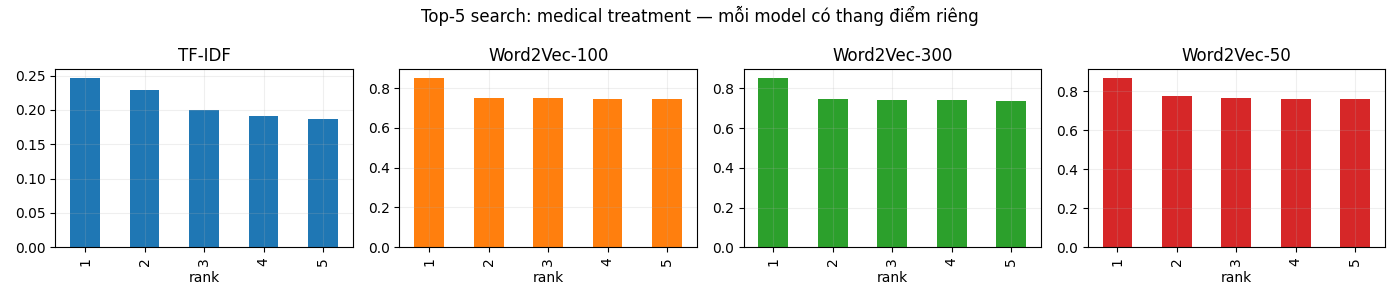

In [18]:
def relevant_snippet(doc_index, query, radius=220):
    text = documents[doc_index]
    terms = [word for word in tokenizer.tokenize_sentence(query) if word not in STOPWORDS]
    first_match = next((match for match in tokenizer.WORD_PATTERN.finditer(text)
                        if match.group().lower() in terms), None)
    center = first_match.start() if first_match is not None else 0
    start = max(0, center - radius // 2)
    return " ".join(text[start:start + 2 * radius].split())


full_bow = document_bow()
full_tfidf, full_transformer = build_tfidf(full_bow)
topic_search_rows = []
for dimension, model in dimension_models.items():
    vectors = document_embeddings(full_bow, model)
    valid_documents = np.linalg.norm(vectors, axis=1) > 0
    for query in TOPIC_QUERIES:
        query_vector, coverage = query_embedding(query, model)
        if np.linalg.norm(query_vector) == 0:
            print(f"Query OOV ở {dimension} chiều: {query}")
            continue
        scores = vectors @ query_vector
        order = rank_documents(scores, valid_documents)[:5]
        for rank, index in enumerate(order, start=1):
            topic_search_rows.append({"model": f"Word2Vec-{dimension}", "dimension": dimension,
                "query": query, "rank": rank, "doc_id": int(index) + 1,
                "jsonl_line": source_line_numbers[int(index)], "cosine": float(scores[index]),
                "token_coverage": coverage, "snippet": relevant_snippet(int(index), query)})
for query in TOPIC_QUERIES:
    scores, coverage = tfidf_query_scores(query, full_tfidf, full_transformer)
    if coverage == 0:
        continue
    order = rank_documents(scores, np.asarray(full_tfidf.getnnz(axis=1)).ravel() > 0)[:5]
    for rank, index in enumerate(order, start=1):
        topic_search_rows.append({"model": "TF-IDF", "dimension": np.nan,
            "query": query, "rank": rank, "doc_id": int(index) + 1,
            "jsonl_line": source_line_numbers[int(index)], "cosine": float(scores[index]),
            "token_coverage": coverage, "snippet": relevant_snippet(int(index), query)})
topic_search_results = pd.DataFrame(topic_search_rows, columns=[
    "model", "dimension", "query", "rank", "doc_id", "jsonl_line", "cosine", "token_coverage", "snippet"])


def show_search_results(query="medical treatment"):
    selected = topic_search_results[topic_search_results["query"] == query]
    if selected.empty:
        print("Query chưa có kết quả; hãy xem coverage.")
        return
    for name, rows in selected.groupby("model", sort=False):
        display(Markdown(f"### {query} — {name}"))
        show_table(rows[["rank", "doc_id", "jsonl_line", "cosine", "snippet"]])


def plot_search_results(query="medical treatment"):
    selected = topic_search_results[topic_search_results["query"] == query]
    if selected.empty:
        print("Query chưa có dữ liệu")
        return
    table = selected.pivot(index="rank", columns="model", values="cosine")
    table.plot.bar(subplots=True, layout=(1, len(table.columns)), sharey=False,
                   title=list(table.columns), legend=False, figsize=(14, 3))
    plt.suptitle(f"Top-5 search: {query} — mỗi model có thang điểm riêng")
    plt.tight_layout()
    plt.show()
    plt.close()


show_search_results("medical treatment")
plot_search_results("medical treatment")

### Đọc kết quả semantic search từ corpus thật

**Medical treatment:** Word2Vec-100 Top-1 là Doc **9421**, cosine **0,8519**,
có các đoạn “Screening and treatment for cancer” và “Mammography … Treatment”.
TF-IDF cũng đưa Doc này lên Top-1 nhưng cosine **0,2467**; không so hai điểm để kết luận
Word2Vec tốt hơn. Word2Vec đưa Doc **281** lên Top-2 (**0,7502**), nói về giảm đau cho
“cancer patients” và “palliative care”; Doc **3667** Top-3 (**0,7484**) nói điều trị
bệnh nhân và phục hình nha khoa. Những context này hỗ trợ mức liên quan y tế, dù
không phải tất cả đều chứa đúng toàn bộ cụm query. Doc **1584/8438** là tiểu sử bác sĩ
và chuyên gia y tế: cùng chủ đề nhưng có thể kém phù hợp nếu người dùng muốn hướng dẫn điều trị.

**Football match:** Word2Vec-100 Top-1 là Doc **6083**, cosine **0,8512**,
chứa các câu lặp “replica football shirt” và từ ngữ không mạch lạc; không phải
tài liệu rõ ràng về một trận đấu. Điều này nhất quán với football→replica ở Top-5 words.
TF-IDF Top-1 là Doc **7667** (**0,2577**), có các trường “Referee”, “Home Team”,
“Visitor”, “League or playoff match”, phù hợp hơn với query về trận đấu khi đọc nội dung.
Đây là nhận xét của các ví dụ cụ thể, chưa phải relevance accuracy trên cả bộ query.

**Computer software:** Word2Vec-100 Top-1 Doc **3821** (**0,8434**) là nội dung dịch vụ
sửa máy tính/IT; các Doc **7772, 4751, 6068, 7614** nói tải phần mềm, chuyển đổi dữ liệu,
RoboHelp hoặc công cụ developer. TF-IDF Top-1 Doc **834** (**0,3420**) lặp “Computer
software engineers” và nói tiền lương. Cả hai có thể cùng chủ đề, nhưng ý định query
chưa được xác định là tải phần mềm, sửa máy hay nghề nghiệp. Cần đọc snippet/nội dung để đánh giá.

**River bank:** Word2Vec-100 Top-1 Doc **9192** (**0,7889**) nói về công viên,
Doc **2297/2907/257** chủ yếu mô tả địa điểm, đường đi hoặc khu thương mại; các đoạn trích
này chưa chứng minh chúng nói về bờ sông. TF-IDF đưa Doc **5609** ở Top-2 (**0,1963**),
nội dung “National Bank … branch locations”: khớp từ bank nhưng sai nghĩa bờ sông.
Doc **6657** ở Top-4 của TF-IDF nói về Nho Que River và đi thuyền, cho thấy phải phân biệt
khớp từ khóa với đúng nghĩa trong context. Một vector bank cố định và trung bình vector
của query chưa bảo đảm giải nghĩa đúng cụm river bank.

**Giới hạn của ứng dụng:** Mean word vectors bỏ thứ tự từ, không mô hình hóa phủ định,
quan hệ giữa các thành phần hoặc ý định query. Documents dài và mẫu trang web lặp
có thể chi phối trung bình. Các query chủ đề chưa có relevance labels, nên không
ghi accuracy hoặc tuyên bố phương pháp thắng trên toàn bộ semantic search.
Có thể kiểm tra cải thiện bằng cách lọc trang nhiễu, chia document thành đoạn, thử
trọng số TF-IDF cho word vectors và đánh giá trên các nhãn relevance độc lập.


## Xuất kết quả CSV

Chạy sau các thí nghiệm. Mỗi dòng có `record_type` và `experiment` để phân
biệt training, similarity, analogy, retrieval và bằng chứng corpus.
Dữ liệu được dựng lại từ các bảng hiện tại, tránh lặp dòng khi chạy lại cell.


In [19]:
training_table = pd.DataFrame([training_record(model) for model in model_cache.values()])
corpus_examples = pd.concat([context_examples(word) for word in sorted(focus_words)], ignore_index=True)
tables = {
    "cooccurrence_statistics": ("10", cooccurrence_statistics),
    "cooccurrence_similarity": ("10", cooccurrence_similarities),
    "training": ("17/19/20", training_table),
    "top5_neighbors": ("18", inspection_table),
    "shared_context": ("18", context_evidence_table),
    "corpus_context": ("18", corpus_examples),
    "window_similarity": ("19", window_similarity_long),
    "dimension_similarity": ("20", dimension_similarity_long),
    "analogy": ("20/22", analogy_details),
    "analogy_summary": ("20/22", analogy_summary),
    "retrieval_query_source": ("20", retrieval_cases),
    "known_item_retrieval": ("20", retrieval_details),
    "retrieval_summary": ("20", retrieval_summary),
    "corpus_topic_search": ("24", topic_search_results),
    "dimension_summary": ("20", dimension_summary),
    "word_similarity_evaluation": ("21", word_similarity_evaluation),
}
results = pd.concat([
    table.assign(record_type=name, experiment=experiment, documents=len(documents))
    for name, (experiment, table) in tables.items()
], ignore_index=True)
if EXPORT_RESULTS:
    results_path = LAB_DIR / "results.csv"
    results.to_csv(results_path, index=False, encoding="utf-8-sig")
    print(f"Đã lưu {len(results):,} dòng: {results_path}")
show_table(results.groupby(["experiment", "record_type"], sort=False).size().reset_index(name="rows"))

,experiment,record_type,rows
0,10,cooccurrence_statistics,3
1,10,cooccurrence_similarity,18
2,17/19/20,training,5
3,18,top5_neighbors,35
4,18,shared_context,35
5,18,corpus_context,80
6,19,window_similarity,18
7,20,dimension_similarity,18
8,20/22,analogy,9
9,20/22,analogy_summary,3
